# Test zavolab_pyutils Module

Testing the `read_count_data_analysis` module with sample data

In [14]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# this is important to be able to re-import the module after making modifications to the zavolab_pyutils code on Scicore

import pandas as pd
import numpy as np
from zavolab_pyutils.read_count_data_analysis import deseq2_normalize
from zavolab_pyutils.visualization import plot_size_factors

from zavolab_pyutils.read_count_data_analysis import model_mean_variance
from zavolab_pyutils.visualization import plot_mean_variance_diagnostics, plot_gene_expression_with_ci

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
?deseq2_normalize

Signature: deseq2_normalize(counts_df, sample_list, lowExprGenesQ=0.3, pseudocount=1)
Docstring:
Performs DESeq2-style median-of-ratios normalization.

Assumes inputs are validated (sample_list exists in counts_df columns).

Parameters
----------
counts_df : pd.DataFrame
    Raw count matrix (genes x samples). May contain any additional columns, e.g. gene names, gene lengths etc.
sample_list : list
    List of column names in counts_df to normalize.
lowExprGenesQ: float
    the quantile specifying the threshold to discard low-expressed genes for size factor calculation
pseudocount: float
    added count before dividing by size factor value. Essential if further log2 transformation is performed.
    
Returns
-------
norm_counts : pd.DataFrame
    Dataframe of normalized counts (same shape as input).
sfs_df : pd.DataFrame
    Dataframe containing calculated size factors and read sums.
File:      ~/libs/zavolab_pyutils/src/zavolab_pyutils/read_count_data_analysis.py
Type:      function

## Create sample count data

The way we generate the data means that there are NO differentially expressed genes. The only thing that is different is the size factor reflecting library size of samples

In [18]:
# Create sample count matrix (3000 genes x 4 samples)
N_genes = 3000
np.random.seed(42)
genes = [f"Gene_{i}" for i in range(1, N_genes+1)]
samples = ["Sample_1", "Sample_2", "Sample_3", "Sample_4"]

metadata = {
    "sample": samples,
    "condition": ["Control", "Control", "Treatment", "Treatment"]
}
metadata_df = pd.DataFrame(metadata)

# scaling_factors = [1, 2, 3, 4] # reflect true size factors
scaling_factors = [1, 1.2, 0.8, 1.9] # reflect true size factors

# 1. Define true mean expressions for genes
exp_average_vals = np.random.lognormal(3, 3, N_genes)

# 2. Define a realistic constant dispersion (alpha)
# alpha = 0.05 means Variance = Mean + 0.05 * Mean^2
alpha = 0.05
n_param = 1 / alpha

counts_dict = {}
for k, gene in enumerate(genes):
    mu_gene = exp_average_vals[k]
    gene_counts = []
    
    for s, sample in enumerate(samples):
        # 3. Incorporate size factor into the expected mean FIRST
        mu_sample = mu_gene * scaling_factors[s]
        
        # 4. Calculate 'p' dynamically for this specific mean
        p_param = n_param / (n_param + mu_sample)
        
        # Draw the final count (add 1 as pseudocount to avoid all zeros if desired)
        count = np.random.negative_binomial(n_param, p_param) + 1
        gene_counts.append(count)
        
    counts_dict[gene] = gene_counts

counts_df = pd.DataFrame(counts_dict, index=samples, columns=genes).transpose()

print("Input count matrix:")
print(counts_df.head())
print(f"\nShape: {counts_df.shape}")

Input count matrix:
        Sample_1  Sample_2  Sample_3  Sample_4
Gene_1        55        80        89       162
Gene_2        12         9        14        22
Gene_3       147       177       139       366
Gene_4      1442      2099      2081      4903
Gene_5        13        23         7        28

Shape: (3000, 4)


## Apply DESeq2-style normalization

In [19]:
# Apply normalization
norm_counts_df, sfs_df = deseq2_normalize(
    counts_df, 
    sample_list=samples,
    lowExprGenesQ=0.3,
    pseudocount=1
)

print("Normalized count matrix:")
print(norm_counts_df)
print(f"\nShape: {norm_counts_df.shape}")

Normalized count matrix:
              Sample_1     Sample_2     Sample_3     Sample_4
Gene_1       64.600297    78.370506   127.570821    99.955787
Gene_2       14.996498     9.675371    21.261803    14.104191
Gene_3      170.729358   172.221606   198.443499   225.053828
Gene_4     1664.611237  2031.827938  2951.138324  3007.258778
Gene_5       16.150074    23.220891    11.339629    17.783545
...                ...          ...          ...          ...
Gene_2996    25.378688    29.026113    22.679257    34.953864
Gene_2997    46.143070    54.182078    66.620318    53.963861
Gene_2998     3.460730     1.935074     2.834907     1.226451
Gene_2999    66.907451    68.695135    66.620318    79.106114
Gene_3000    17.303651    21.285816    11.339629    21.462899

[3000 rows x 4 columns]

Shape: (3000, 4)


## Size factors and QC metrics

In [20]:
print("Size factors and read metrics:")
print(sfs_df[["sf", "log2_sf", "read_sum", "read_sum_mln"]])

Size factors and read metrics:
                sf   log2_sf    read_sum  read_sum_mln
sample                                                
Sample_1  0.866869 -0.206114   6451807.0          6.45
Sample_2  1.033552  0.047611   9358575.0          9.36
Sample_3  0.705490 -0.503301   6284120.0          6.28
Sample_4  1.630721  0.705510  16693958.0         16.69


## Verify normalization

Check that the median size factor is close to 1 (expected behavior after normalization)

In [22]:
print(f"Median size factor: {sfs_df['sf'].median():.3f}")
print(f"Mean size factor: {sfs_df['sf'].mean():.3f}")
print("\n✓ Normalization completed successfully!")

Median size factor: 0.950
Mean size factor: 1.059

✓ Normalization completed successfully!


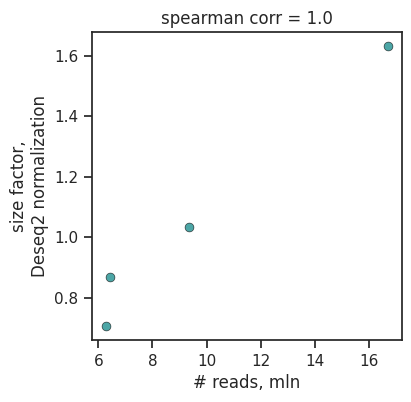

In [23]:
plot_size_factors(sfs_df,outdir='./tests/plots/')

## Mean-Variance Modeling and Confidence Intervals

In [28]:
# Model the condition-specific dispersion using Quantile Regression
regr_model_df, all_plot_data = model_mean_variance(
    norm_counts_df, 
    metadata_df, 
    sample_col='sample', 
    cond_col='condition'
)

print("\nRegression Model Parameters (Alpha/Dispersion):")
print(regr_model_df)


Regression Model Parameters (Alpha/Dispersion):
   condition model_type pred_feature     param
0    Control   QuantReg          var  0.018792
1  Treatment   QuantReg          var  0.018999


In [ ]:
# WARNING: param values should be very similar to the specified value of alpha (see above)!
# CURRENT status: it does not match

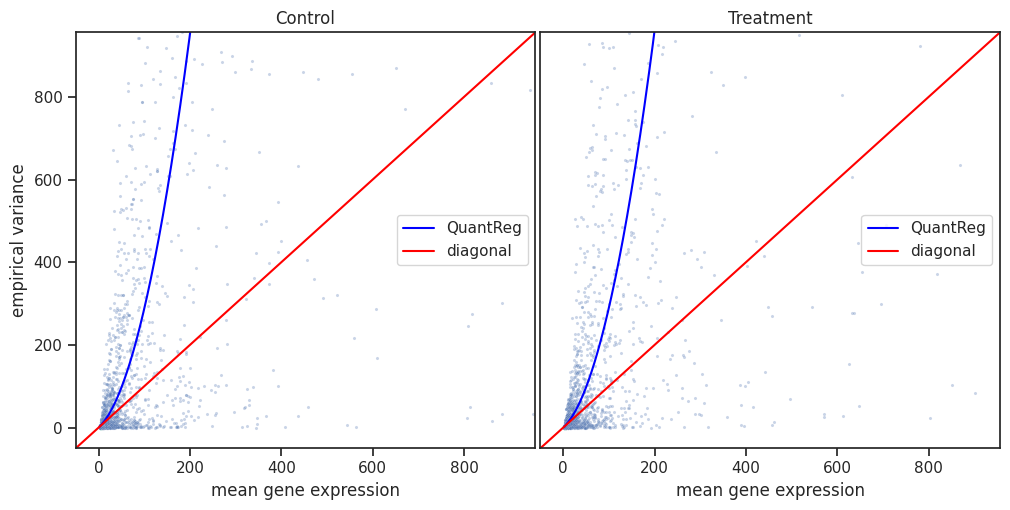

In [29]:
# Plot the diagnostic regression fits for variance within each condition
plot_mean_variance_diagnostics(
    all_plot_data, 
    savefig_path='./tests/plots/mean_variance_diagnostics.png'
)

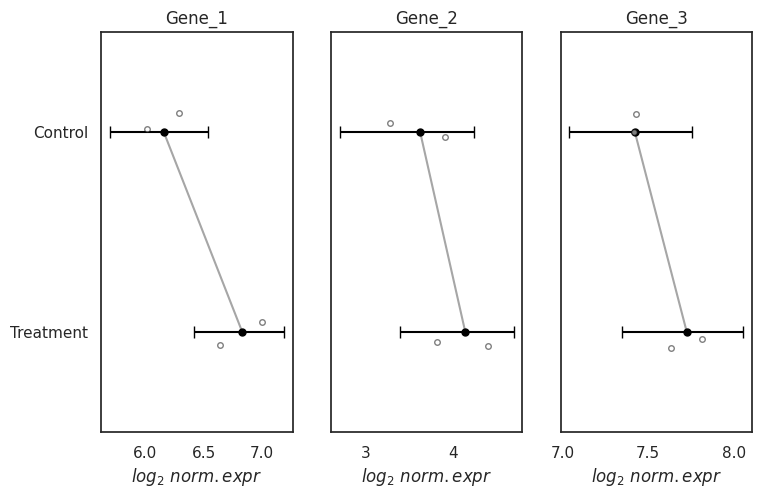

In [30]:
# Select specific genes of interest to visualize their differential expression
selected_genes = ["Gene_1", "Gene_2", "Gene_3"]

# Plot log2 expression with exact Negative Binomial confidence intervals
plot_gene_expression_with_ci(
    norm_counts_df, 
    metadata_df, 
    selected_genes, 
    regr_model_df, 
    savefig_path='./tests/plots/gene_expression_ci.png',
    sample_col='sample', 
    cond_col='condition'
)